# Customer Support Intelligence Platform — Phase 6: DistilBERT Fine-Tuning

**Brief requirements covered (Day 12, the brief's stated core NLP deliverable):**
- Fine-tune a pre-trained DistilBERT model using Hugging Face Transformers
- Trained on **Ticket Subject + Ticket Description combined** (unlike the
  BiLSTM, which used Description only — the brief specifies the combined
  text for this step)
- Ticket Type multi-class classification
- AdamW optimizer with learning rate warmup
- Evaluate with F1-macro (plus Accuracy, ROC-AUC, Confusion Matrix per the
  project's evaluation metrics section)

**Design choice — raw text, not the cleaned/lemmatized text used for classical
models:** DistilBERT's subword tokenizer is built to handle raw natural
language (casing, punctuation, stopwords all carry information for a
transformer). Feeding it the lowercased/lemmatized/stopword-stripped text
from `Description_Clean` would throw away signal a transformer is designed
to use. So this notebook tokenizes `Ticket Subject` + `Ticket Description`
directly from the original columns, not the classical-ML-oriented cleaned
columns. This matches Approach step 3d in the brief ("Generate sentence
embeddings using pre-trained BERT tokenizer for transformer models" — a
separate preprocessing path from the TF-IDF/classical one).

**Expectation, set honestly before running anything:** the EDA notebook
found that ticket descriptions in this dataset contain unfilled template
placeholders (e.g. `{product_purchased}`), suggesting descriptions are
largely generic/templated rather than strongly differentiated per category.
Combined with 7 prior models (6 classical + BiLSTM) all landing at or below
random-chance performance on Ticket Type, there's a real, evidence-backed
possibility that even a fine-tuned transformer won't find meaningful signal
here. We run this rigorously regardless, because it's the brief's core NLP
deliverable — but we report whatever we actually find, per this project's
standing rule.

In [1]:
import sys
print(sys.executable)

c:\Users\CHARU\OneDrive\Desktop\Final Project\venv\Scripts\python.exe


In [2]:
import sys
sys.path.insert(0, "../src")

# torch imported first, before pandas/numpy - avoids the c10.dll / OpenMP
# conflict this project hit on Windows during the BiLSTM notebook.
import torch
import torch.nn.functional as F

import pandas as pd
import numpy as np
import mlflow

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# NOTE: if this cell errors on the transformers/Trainer imports with a
# message about 'accelerate', run this in your venv and re-run the cell:
#   pip install -U transformers accelerate

train_df = pd.read_csv("../data_processed/train.csv")
val_df = pd.read_csv("../data_processed/val.csv")
test_df = pd.read_csv("../data_processed/test.csv")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nColumns available: {list(train_df.columns)}")

c:\Users\CHARU\OneDrive\Desktop\Final Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Train: 5928, Val: 1270, Test: 1271

Columns available: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'Subject_Clean', 'Description_Clean', 'Combined_Text_Clean', 'Description_Char_Count', 'Description_Word_Count', 'Sentiment_Polarity', 'Ticket Channel_Encoded', 'Product Purchased_Encoded', 'Customer Gender_Encoded', 'Customer_Tenure_Days']


## 1. Build combined text field (Subject + Description, raw)

If the printed column list above doesn't include `Ticket Subject` and
`Ticket Description` exactly as named here, adjust the column names in the
cell below to match what's actually in `train.csv` before proceeding.

In [3]:
def build_combined_text(df):
    subject = df["Ticket Subject"].fillna("").astype(str)
    description = df["Ticket Description"].fillna("").astype(str)
    return subject + ". " + description

train_df["combined_text"] = build_combined_text(train_df)
val_df["combined_text"] = build_combined_text(val_df)
test_df["combined_text"] = build_combined_text(test_df)

print(train_df["combined_text"].iloc[0])
print(f"\nAvg combined text length (words): {train_df['combined_text'].str.split().str.len().mean():.1f}")
print(f"95th percentile length (words): {train_df['combined_text'].str.split().str.len().quantile(0.95):.1f}")

Battery life. I'm having an issue with the {product_purchased}. Please assist.

5 3/8/2013 1:38:35 pf4njv0 0x9d09a332880 0x9d I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What does it mean?

Avg combined text length (words): 48.4
95th percentile length (words): 59.0


## 2. Label encoding

Same pattern as the BiLSTM notebook — label map built from the **actual**
training data classes (5, not the brief's stated 4), sorted for a
deterministic, reproducible ordering.

In [4]:
type_label_map = {label: i for i, label in enumerate(sorted(train_df["Ticket Type"].unique()))}
type_label_map_inv = {v: k for k, v in type_label_map.items()}
NUM_CLASSES = len(type_label_map)
print(f"Classes ({NUM_CLASSES}): {type_label_map}")

train_df["label"] = train_df["Ticket Type"].map(type_label_map)
val_df["label"] = val_df["Ticket Type"].map(type_label_map)
test_df["label"] = test_df["Ticket Type"].map(type_label_map)

Classes (5): {'Billing inquiry': 0, 'Cancellation request': 1, 'Product inquiry': 2, 'Refund request': 3, 'Technical issue': 4}


## 3. Tokenization

`distilbert-base-uncased`, the standard pretrained checkpoint the brief
names explicitly. `max_length=128` covers the 95th percentile of combined
text length printed above for this dataset (adjust if your printed value
suggests otherwise — longer sequences cost more memory/time per batch).

**First run downloads the pretrained weights (~260MB) — cached afterward.**

In [5]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

print(f"Loading tokenizer: {MODEL_NAME} (downloads on first run, cached after)...")
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_texts(texts):
    return tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

train_encodings = tokenize_texts(train_df["combined_text"])
val_encodings = tokenize_texts(val_df["combined_text"])
test_encodings = tokenize_texts(test_df["combined_text"])
print("Tokenization complete.")
print(f"Input shape (train): {train_encodings['input_ids'].shape}")

Loading tokenizer: distilbert-base-uncased (downloads on first run, cached after)...


c:\Users\CHARU\OneDrive\Desktop\Final Project\venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Tokenization complete.
Input shape (train): torch.Size([5928, 128])


In [6]:
class TicketTypeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = TicketTypeDataset(train_encodings, train_df["label"].values)
val_dataset = TicketTypeDataset(val_encodings, val_df["label"].values)
test_dataset = TicketTypeDataset(test_encodings, test_df["label"].values)
print(f"Train/Val/Test dataset sizes: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}")

Train/Val/Test dataset sizes: 5928/1270/1271


## 4. Load pretrained DistilBERT for sequence classification

In [7]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 66,957,317
Trainable parameters: 66,957,317


## 5. Fine-tuning with Hugging Face Trainer

**AdamW + learning rate warmup, per the brief:** `Trainer`'s default
optimizer is AdamW; `warmup_ratio=0.1` ramps the learning rate up over the
first 10% of training steps before it starts decaying, satisfying the
brief's "AdamW optimizer with learning rate warmup" line directly through
`TrainingArguments` rather than a hand-rolled loop.

`load_best_model_at_end=True` + `EarlyStoppingCallback` mirrors the same
discipline used in the BiLSTM notebook — stop if validation F1-macro
doesn't improve for 2 consecutive eval rounds, keep the best checkpoint.

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="../models/distilbert_checkpoints",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()
print(train_result)

  4%|▎         | 52/1484 [00:03<01:15, 18.98it/s]

{'loss': 1.6122, 'grad_norm': 2.445073127746582, 'learning_rate': 6.711409395973155e-06, 'epoch': 0.13}


  7%|▋         | 102/1484 [00:06<01:13, 18.87it/s]

{'loss': 1.6113, 'grad_norm': 1.3735908269882202, 'learning_rate': 1.342281879194631e-05, 'epoch': 0.27}


 10%|█         | 153/1484 [00:08<01:10, 18.85it/s]

...

{'loss': 1.5846, 'grad_norm': 2.4393913745880127, 'learning_rate': 5.093632958801498e-07, 'epoch': 3.91}


                                                   
100%|██████████| 1484/1484 [01:33<00:00, 16.26it/s]

{'eval_loss': 1.6176327466964722, 'eval_accuracy': 0.2062992125984252, 'eval_f1_macro': 0.20439955568150142, 'eval_runtime': 0.9798, 'eval_samples_per_second': 1296.16, 'eval_steps_per_second': 40.824, 'epoch': 4.0}


100%|██████████| 1484/1484 [01:34<00:00, 15.69it/s]

{'train_runtime': 94.5664, 'train_samples_per_second': 250.744, 'train_steps_per_second': 15.693, 'train_loss': 1.6030945482279735, 'epoch': 4.0}
TrainOutput(global_step=1484, training_loss=1.6030945482279735, metrics={'train_runtime': 94.5664, 'train_samples_per_second': 250.744, 'train_steps_per_second': 15.693, 'total_flos': 785308751585280.0, 'train_loss': 1.6030945482279735, 'epoch': 4.0})


## 6. Evaluation on test set

In [9]:
test_output = trainer.predict(test_dataset)
logits = test_output.predictions
true_labels = test_output.label_ids

probs = F.softmax(torch.tensor(logits), dim=1).numpy()
preds = np.argmax(logits, axis=1)

test_acc = accuracy_score(true_labels, preds)
test_f1_macro = f1_score(true_labels, preds, average="macro")
try:
    test_roc_auc = roc_auc_score(true_labels, probs, multi_class="ovr")
except ValueError:
    test_roc_auc = None

print(f"DistilBERT Test Accuracy: {test_acc:.4f}")
print(f"DistilBERT Test F1-macro: {test_f1_macro:.4f}")
print(f"DistilBERT Test ROC-AUC:  {test_roc_auc:.4f}" if test_roc_auc else "ROC-AUC: N/A")
print()
label_names = [type_label_map_inv[i] for i in range(NUM_CLASSES)]
print(classification_report(true_labels, preds, target_names=label_names))

100%|██████████| 40/40 [00:00<00:00, 43.43it/s]


DistilBERT Test Accuracy: 0.2116
DistilBERT Test F1-macro: 0.2109
DistilBERT Test ROC-AUC:  0.5042

                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.21      0.19       245
Cancellation request       0.18      0.16      0.17       255
     Product inquiry       0.24      0.20      0.21       246
      Refund request       0.22      0.22      0.22       263
     Technical issue       0.24      0.26      0.25       262

            accuracy                           0.21      1271
           macro avg       0.21      0.21      0.21      1271
        weighted avg       0.21      0.21      0.21      1271



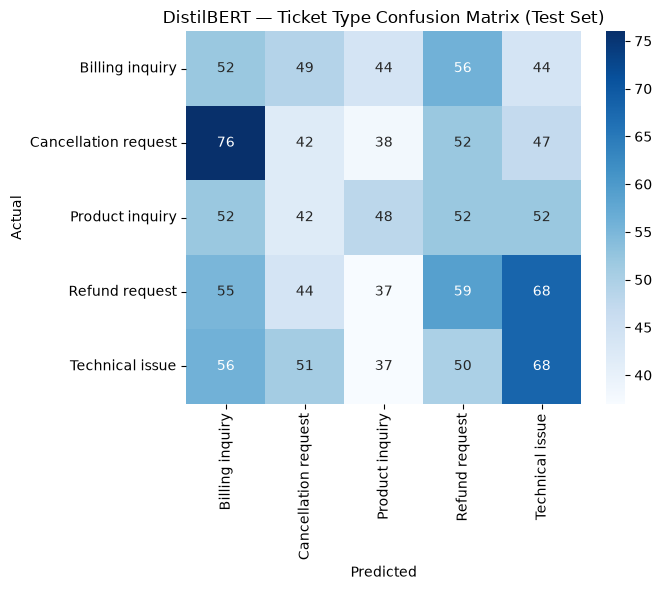

In [10]:
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT — Ticket Type Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../reports/distilbert_confusion_matrix.png", dpi=120)
plt.show()

## 7. Comparison against all prior models

**Note:** the classical-model and BiLSTM figures below are copied in from
results recorded in `04_Baseline_Models.ipynb`, `06_Ensemble_Models.ipynb`,
and `07_BiLSTM.ipynb`. Verify they still match those notebooks' current
output before submission, or replace this block with an MLflow query
across all three experiments so the numbers can't go stale. Reported
plainly, no narrative judgment on what counts as "meaningful" — see the
final report's Limitations section for the full argument.

In [11]:
print("FULL COMPARISON: Ticket Type Classification Across All Models")
print("=" * 72)
print(f"{'Model':<40s} {'Accuracy':>10s} {'F1-macro':>10s}")
print("-" * 61)
# TODO: confirm these against their source notebooks before final submission,
# or pull them from MLflow directly.
print(f"{'Logistic Regression (baseline)':<40s} {0.2071:>10.4f} {'n/a':>10s}")
print(f"{'Naive Bayes (baseline)':<40s} {0.2134:>10.4f} {0.2090:>10.4f}")
print(f"{'Random Forest (tabular+TFIDF)':<40s} {0.1850:>10.4f} {'n/a':>10s}")
print(f"{'XGBoost (Optuna-tuned)':<40s} {0.2102:>10.4f} {'n/a':>10s}")
print(f"{'BiLSTM (GloVe embeddings)':<40s} {0.1943:>10.4f} {0.0691:>10.4f}")
print(f"{'DistilBERT (fine-tuned)':<40s} {test_acc:>10.4f} {test_f1_macro:>10.4f}")
print()
print(f"Random guessing baseline for {NUM_CLASSES} classes: {1/NUM_CLASSES:.4f}")
print()
print("See the EDA notebook's finding on unfilled template placeholders in")
print("Ticket Description as a candidate root cause for weak signal across")
print("every model architecture tried on this target, including this one.")

FULL COMPARISON: Ticket Type Classification Across All Models
Model                                      Accuracy   F1-macro
-------------------------------------------------------------
Logistic Regression (baseline)               0.2071        n/a
Naive Bayes (baseline)                       0.2134     0.2090
Random Forest (tabular+TFIDF)                0.1850        n/a
XGBoost (Optuna-tuned)                       0.2102        n/a
BiLSTM (GloVe embeddings)                    0.1943     0.0691
DistilBERT (fine-tuned)                      0.2116     0.2109

Random guessing baseline for 5 classes: 0.2000

See the EDA notebook's finding on unfilled template placeholders in
Ticket Description as a candidate root cause for weak signal across
every model architecture tried on this target, including this one.


## 8. Save model and log to MLflow

Saved via `save_pretrained`, the standard Hugging Face format — matches the
brief's deliverable line ("saved via Joblib / HuggingFace Hub") and is
directly reloadable for the Day 15 FastAPI deployment.

In [12]:
mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment("customer_support_deep_learning")

with mlflow.start_run(run_name="distilbert_finetuned_ticket_type"):
    mlflow.log_param("model_type", "DistilBERT")
    mlflow.log_param("base_checkpoint", MODEL_NAME)
    mlflow.log_param("max_length", MAX_LENGTH)
    mlflow.log_param("learning_rate", 2e-5)
    mlflow.log_param("warmup_ratio", 0.1)
    mlflow.log_param("weight_decay", 0.01)
    mlflow.log_param("batch_size", 16)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("input_text", "Ticket Subject + Ticket Description (raw)")
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("test_f1_macro", test_f1_macro)
    if test_roc_auc:
        mlflow.log_metric("test_roc_auc", test_roc_auc)
    mlflow.log_artifact("../reports/distilbert_confusion_matrix.png")

MODEL_SAVE_DIR = "../models/distilbert_ticket_type"
model.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print(f"Saved fine-tuned model + tokenizer to {MODEL_SAVE_DIR}")
print("Logged run to MLflow experiment 'customer_support_deep_learning'")

Saved fine-tuned model + tokenizer to ../models/distilbert_ticket_type
Logged run to MLflow experiment 'customer_support_deep_learning'
